# Hospital Capacity & Patient-Flow Data Profiler

**Macro-sector:** Health & Life Sciences &nbsp;|&nbsp; **Sector:** Hospitals & Clinical Operations

**Problem:** build a reproducible data workflow for hospital operations teams to understand
capacity and patient-flow planning — profiling schema, missingness, outliers, trends,
segments and data limitations **without training a predictive model.**

**Datasets:** a 2025 baseline export and a 2026 comparison export from four hospitals
(`HOSP_A`–`HOSP_D`), logged daily per department, sourced from four different hospital
IT systems (`HIS_A`, `HIS_B`, `BedBoard`, `Manual_CSV`) — which is exactly why the raw
files contain inconsistent date formats, free-text quality flags and occasional
impossible values; this notebook treats that messiness as the point of the exercise,
not noise to paper over.

**Pipeline:** load → data dictionary → quality profiling → cleaning → quality report
(before/after) → feature engineering → segment analysis → 5 charts → insight memo →
data limitations → responsible-use notes.

**Scope note:** this is a *descriptive* analytics notebook by design (no model is
trained, no predictions are made) — that matches the brief and keeps clinical-safety
risk low.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dateutil import parser as dateutil_parser
import json
import os

pd.set_option("display.max_columns", None)
plt.rcParams["figure.facecolor"] = "white"

RAW_BASELINE_PATH = "dataset1_baseline_2025.csv"
RAW_COMPARISON_PATH = "dataset2_comparison_2026.csv"
CHART_DIR = "charts"
os.makedirs(CHART_DIR, exist_ok=True)

## 2. Load Raw Data

In [2]:
baseline_raw = pd.read_csv(RAW_BASELINE_PATH)
comparison_raw = pd.read_csv(RAW_COMPARISON_PATH)

print("Baseline shape:", baseline_raw.shape)
print("Comparison shape:", comparison_raw.shape)
baseline_raw.head()

Baseline shape: (2908, 26)
Comparison shape: (2908, 26)


,record_id,date,period,hospital_id,hospital_name,region,department,total_beds,operational_beds,occupied_beds_morning,admissions,discharges,transfers_in,transfers_out,emergency_arrivals,elective_surgeries,cancellations,staff_nurses,staff_doctors,avg_wait_time_min,median_wait_time_min,bed_turnover_time_hr,patients_left_without_seen,isolation_beds_used,source_system,notes
0,B2025_00001,2025-01-01,Baseline_2025_Jan_Apr,HOSP_A,CityCare General Hospital,North,Emergency,40,39,37.0,11,10.0,0,2,37,0,0,10.0,5,112.7,75.3,5.1,2,1,HIS_A,NaN
1,B2025_00002,2025-01-01,Baseline_2025_Jan_Apr,HOSP_A,CityCare General Hospital,North,ICU,28,28,30.0,5,8.0,2,1,0,0,0,16.0,4,74.7,54.6,7.5,0,0,BedBoard,NaN
2,B2025_00003,2025-01-01,Baseline_2025_Jan_Apr,HOSP_A,CityCare General Hospital,North,General Medicine,74,72,70.0,12,15.0,3,2,2,0,0,13.0,3,79.9,53.6,4.8,0,4,HIS_B,NaN
3,B2025_00004,2025-01-01,Baseline_2025_Jan_Apr,HOSP_A,CityCare General Hospital,North,Surgery,52,49,45.0,9,8.0,1,1,1,19,2,10.0,2,69.9,58.7,5.3,0,2,HIS_B,NaN
4,B2025_00005,2025-01-01,Baseline_2025_Jan_Apr,HOSP_A,CityCare General Hospital,North,Pediatrics,38,38,33.0,2,2.0,4,2,1,0,1,5.0,3,68.2,43.8,4.8,0,0,HIS_B,NaN


## 3. Data Dictionary

A deliverable that's easy to skip but that any hospital ops team picking this up later
will need: what every column means, its unit, and what a "valid" value looks like.
Includes the engineered columns added later in the notebook.

In [3]:
DATA_DICTIONARY = [
    ("record_id", "string", "Unique row identifier", "-", "unique"),
    ("date", "date", "Calendar date of the daily department record", "date", "within reporting period"),
    ("period", "string", "Reporting batch label", "-", "categorical"),
    ("hospital_id", "string", "Hospital code", "-", "HOSP_A..D"),
    ("hospital_name", "string", "Hospital full name", "-", "categorical"),
    ("region", "string", "Geographic region of the hospital", "-", "North/South/East/West"),
    ("department", "string", "Hospital department", "-", "categorical (standardised)"),
    ("total_beds", "integer", "Total bed capacity of the department", "beds", ">= operational_beds"),
    ("operational_beds", "integer", "Beds currently staffed/usable", "beds", "<= total_beds"),
    ("occupied_beds_morning", "float", "Beds occupied at the morning census", "beds", "<= operational_beds"),
    ("admissions", "integer", "Patients admitted that day", "patients", ">= 0"),
    ("discharges", "float", "Patients discharged that day", "patients", ">= 0"),
    ("transfers_in", "integer", "Patients transferred into the department", "patients", ">= 0"),
    ("transfers_out", "integer", "Patients transferred out of the department", "patients", ">= 0"),
    ("emergency_arrivals", "integer", "Emergency arrivals that day (structurally concentrated in Emergency dept.)", "patients", ">= 0"),
    ("elective_surgeries", "integer", "Elective surgeries performed", "procedures", ">= 0"),
    ("cancellations", "integer", "Cancelled procedures", "procedures", ">= 0"),
    ("staff_nurses", "float", "Nurses on duty", "staff", ">= 0"),
    ("staff_doctors", "integer", "Doctors on duty", "staff", ">= 0"),
    ("avg_wait_time_min", "float", "Average patient wait time", "minutes", ">= 0"),
    ("median_wait_time_min", "float", "Median patient wait time", "minutes", ">= 0"),
    ("bed_turnover_time_hr", "float", "Average time to turn over a bed between patients", "hours", ">= 0"),
    ("patients_left_without_seen", "integer", "Patients who left before being seen", "patients", ">= 0"),
    ("isolation_beds_used", "integer", "Isolation beds in use", "beds", ">= 0"),
    ("source_system", "string", "Originating IT system - proxy for data lineage", "-", "HIS_A/HIS_B/BedBoard/Manual_CSV"),
    ("notes", "string", "Free-text data-quality flag entered by an analyst (mostly blank)", "-", "free text"),
    ("occupancy_rate", "float (derived)", "occupied_beds_morning / operational_beds", "ratio", "0-1"),
    ("capacity_status", "string (derived)", "Normal / High / Critical band based on occupancy_rate", "-", "categorical"),
    ("patient_turnover", "integer (derived)", "admissions + discharges", "patients", ">= 0"),
    ("net_patient_flow", "integer (derived)", "admissions - discharges", "patients", "can be negative"),
    ("patients_per_staff", "float (derived)", "occupied_beds_morning / (staff_nurses + staff_doctors)", "ratio", ">= 0"),
    ("capacity_flag", "boolean (derived)", "True if occupied beds originally exceeded operational beds (data-entry error, capped)", "-", "True/False"),
]
data_dictionary = pd.DataFrame(
    DATA_DICTIONARY, columns=["column", "type", "description", "unit", "valid_range"]
)
data_dictionary

,column,type,description,unit,valid_range
0,record_id,string,Unique row identifier,-,unique
1,date,date,Calendar date of the daily department record,date,within reporting period
2,period,string,Reporting batch label,-,categorical
3,hospital_id,string,Hospital code,-,HOSP_A..D
4,hospital_name,string,Hospital full name,-,categorical
5,region,string,Geographic region of the hospital,-,North/South/East/West
6,department,string,Hospital department,-,categorical (standardised)
7,total_beds,integer,Total bed capacity of the department,beds,>= operational_beds
8,operational_beds,integer,Beds currently staffed/usable,beds,<= total_beds
9,occupied_beds_morning,float,Beds occupied at the morning census,beds,<= operational_beds


## 4. Schema & Missingness Profiling

In [4]:
def profile_data(df, name):
    print(f"\n========== {name} DATA PROFILE ==========")
    print("\nShape:", df.shape)
    print("\nData types:\n", df.dtypes)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nNumeric summary:\n", df.describe())

profile_data(baseline_raw, "Baseline 2025")
profile_data(comparison_raw, "Comparison 2026")


========== Baseline 2025 DATA PROFILE ==========

Shape: (2908, 26)

Data types:
 record_id                         str
date                              str
period                            str
hospital_id                       str
hospital_name                     str
region                            str
department                        str
total_beds                      int64
operational_beds                int64
occupied_beds_morning         float64
admissions                      int64
discharges                    float64
transfers_in                    int64
transfers_out                   int64
emergency_arrivals              int64
elective_surgeries              int64
cancellations                   int64
staff_nurses                  float64
staff_doctors                   int64
avg_wait_time_min             float64
median_wait_time_min          float64
bed_turnover_time_hr          float64
patients_left_without_seen      int64
isolation_beds_used             int64
sourc

## 5. Data-Quality Report (Before Cleaning)

Beyond simple null counts, this checks for the kinds of *silent* problems that
matter operationally: duplicate rows, dates that won't parse, capacity logic
violations (occupied beds > operational beds), and impossible negative values.

In [5]:
def parse_mixed_dates(series, year, period_start_month=1, period_end_month=4):
    """Parses a column containing a mix of ISO, slash and dash date formats,
    validating the result against the dataset's known reporting period
    (Jan-Apr) and retrying the opposite day/month convention for any value
    that parses outside that window. Returns (parsed_series, unresolved_mask)."""
    def _dateutil_safe(x, dayfirst):
        try:
            return dateutil_parser.parse(x, dayfirst=dayfirst)
        except Exception:
            return pd.NaT

    s = series.astype(str).str.strip()
    parsed = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")

    mask = parsed.isna()
    if mask.any():
        parsed.loc[mask] = pd.to_datetime(s[mask], format="%Y/%m/%d", errors="coerce")

    mask = parsed.isna()
    if mask.any():
        parsed.loc[mask] = pd.to_datetime(s[mask].apply(lambda x: _dateutil_safe(x, True)))

    lo, hi = pd.Timestamp(year, period_start_month, 1), pd.Timestamp(year, period_end_month, 30)
    out_of_range = (parsed < lo) | (parsed > hi) | parsed.isna()
    if out_of_range.any():
        retry = pd.to_datetime(s[out_of_range].apply(lambda x: _dateutil_safe(x, False)))
        fixed_ok = (retry >= lo) & (retry <= hi)
        parsed.loc[out_of_range[out_of_range].index[fixed_ok.values]] = retry[fixed_ok]

    still_bad = parsed.isna() | (parsed < lo) | (parsed > hi)
    return parsed, still_bad


def quality_report(df, name, year):
    report = {"name": name, "rows": len(df), "duplicate_rows": int(df.duplicated().sum())}
    df2 = df.copy()
    df2.columns = df2.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
    report["missing_pct"] = (df2.isnull().mean() * 100).round(2).to_dict()
    if {"occupied_beds_morning", "operational_beds"}.issubset(df2.columns):
        report["capacity_violations"] = int((df2["occupied_beds_morning"] > df2["operational_beds"]).sum())
    if "date" in df2.columns:
        _, bad_dates = parse_mixed_dates(df2["date"], year)
        report["unparseable_dates_before_fix"] = int(bad_dates.sum())
    neg_cols = {}
    for c in ["admissions", "discharges", "transfers_in", "transfers_out", "staff_nurses", "staff_doctors"]:
        if c in df2.columns:
            n = int((df2[c] < 0).sum())
            if n:
                neg_cols[c] = n
    report["negative_value_counts"] = neg_cols
    return report


quality_before = {
    "baseline_2025": quality_report(baseline_raw, "baseline_2025", 2025),
    "comparison_2026": quality_report(comparison_raw, "comparison_2026", 2026),
}
print(json.dumps(quality_before, indent=2, default=str))

{
  "baseline_2025": {
    "name": "baseline_2025",
    "rows": 2908,
    "duplicate_rows": 28,
    "missing_pct": {
      "record_id": 0.0,
      "date": 0.0,
      "period": 0.0,
      "hospital_id": 0.0,
      "hospital_name": 0.0,
      "region": 0.0,
      "department": 0.58,
      "total_beds": 0.0,
      "operational_beds": 0.0,
      "occupied_beds_morning": 0.96,
      "admissions": 0.0,
      "discharges": 0.79,
      "transfers_in": 0.0,
      "transfers_out": 0.0,
      "emergency_arrivals": 0.0,
      "elective_surgeries": 0.0,
      "cancellations": 0.0,
      "staff_nurses": 1.17,
      "staff_doctors": 0.0,
      "avg_wait_time_min": 1.75,
      "median_wait_time_min": 0.0,
      "bed_turnover_time_hr": 0.0,
      "patients_left_without_seen": 0.0,
      "isolation_beds_used": 0.0,
      "source_system": 0.0,
      "notes": 95.46
    },
    "capacity_violations": 115,
    "unparseable_dates_before_fix": 0,
    "negative_value_counts": {
      "discharges": 11
    }
  },

## 6. Issues Found In This Dataset (and why the cleaning step below handles them the way it does)

Profiling the raw data surfaced six concrete problems worth calling out explicitly,
because each one would silently corrupt the analysis if handled the "obvious" way:

1. **Mixed date formats.** The `date` column mixes ISO (`2025-01-01`), slash
   (`2025/01/07`), and ambiguous day/month order (`04/01/2025`, `30-03-2025`) —
   a direct consequence of four different source systems feeding the same column.
   A plain `pd.to_datetime(..., errors="coerce")` either drops rows (NaT) or, worse,
   *silently* mis-parses ambiguous dates with no error at all. The parser below
   validates every parsed date against that record's known reporting window
   (Jan–Apr) and retries the opposite day/month convention when a date lands
   outside it.
2. **The `notes` column is 95% blank by design** (it's a flag an analyst adds only
   when something looks off — `wait-time outlier`, `date format check`, etc.).
   Filling missing values with the column **mode** turns ~95% of genuinely clean
   rows into `"capacity reconciliation needed"`, fabricating a data-quality
   incident that never happened. This column is excluded from mode-imputation.
3. **Global outlier clipping mixes departments that shouldn't be compared.**
   `emergency_arrivals` legitimately averages ~30/day in Emergency and ~1/day
   everywhere else — that's not noise, it's what the column means. Clipping by a
   single dataset-wide IQR bound collapses Emergency's real signal down to ~7.5,
   erasing it entirely. Outlier clipping below is scoped **per department** and
   limited to genuinely continuous duration metrics (wait/turnover times) rather
   than applied blindly to every numeric column.
4. **Capacity logic violations aren't checked at all in a naive pipeline**: in both
   files, around 100 rows record more occupied beds than operational beds — a
   physical impossibility. These are capped and flagged (not silently dropped).
5. **A non-obvious "second-order" version of issue #1**: any numeric imputation or
   clipping that groups by `department` will silently *drop* rows where
   `department` is still `NaN` (`pandas.groupby` excludes null keys from every
   group). `department` is therefore filled before it is used as a grouping key
   anywhere downstream.
6. **Negative values** (e.g. `discharges` as low as -4) are physically impossible
   and are treated as missing, then imputed — not left in place.

Each fix below is intentionally scoped to the smallest change that resolves the
issue, so the rest of the original pipeline's logic and structure is preserved.

## 7. Cleaning Function (fixed)

In [6]:
TEXT_COLS = ["record_id", "hospital_id", "hospital_name", "region", "department",
             "source_system", "notes", "period"]
NUMERIC_COLS = ["total_beds", "operational_beds", "occupied_beds_morning", "admissions",
                 "discharges", "transfers_in", "transfers_out", "emergency_arrivals",
                 "elective_surgeries", "cancellations", "staff_nurses", "staff_doctors",
                 "avg_wait_time_min", "median_wait_time_min", "bed_turnover_time_hr",
                 "patients_left_without_seen", "isolation_beds_used"]
# Only continuous duration/rate metrics get outlier clipping - count metrics
# (admissions, emergency_arrivals, etc.) are left untouched: their department-to-
# department variation is real clinical signal, not noise (see section 6, point 3).
CLIP_COLS = ["avg_wait_time_min", "median_wait_time_min", "bed_turnover_time_hr"]
DEPARTMENT_MAP = {
    "Er": "Emergency", "Emergency Room": "Emergency", "Emergency Dept": "Emergency",
    "Icu": "ICU", "Intensive Care Unit": "ICU", "Intensive Care": "ICU",
    "Opd": "OPD", "Out Patient": "OPD", "Outpatient": "OPD",
    "Paeds": "Pediatrics", "Medical Ward": "General Medicine",
    "Surgical Ward": "Surgery", "Obstetrics": "Maternity",
}


def clean_hospital_data(df_raw, year):
    df = df_raw.copy()
    df.columns = (df.columns.str.strip().str.lower()
                  .str.replace(" ", "_").str.replace("-", "_"))

    n_before = len(df)
    df = df.drop_duplicates()
    n_duplicates_removed = n_before - len(df)

    # text columns: trim whitespace only, leave real NaN as real NaN
    for col in TEXT_COLS:
        if col in df.columns:
            df[col] = df[col].astype("string").str.strip()

    # standardise department labels, then fill NaN immediately - department
    # is used as a groupby key below, and groupby() silently drops NaN-key rows
    if "department" in df.columns:
        df["department"] = df["department"].str.lower().str.title()
        df["department"] = df["department"].replace(DEPARTMENT_MAP)
        if df["department"].isnull().sum() > 0:
            df["department"] = df["department"].fillna(df["department"].mode()[0])

    # robust date parsing (see section 6, point 1)
    parsed_dates, unresolved = parse_mixed_dates(df["date"], year)
    df["date"] = parsed_dates
    n_unresolved_dates = int(unresolved.sum())

    # numeric columns: coerce to numeric
    for col in NUMERIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # flag impossible negative values, then null them out (section 6, point 6)
    for col in NUMERIC_COLS:
        if col in df.columns:
            df.loc[df[col] < 0, col] = np.nan

    # impute missing numerics with the DEPARTMENT-level median (not a single
    # global median - departments differ hugely in scale)
    for col in NUMERIC_COLS:
        if col in df.columns:
            dept_median = df.groupby("department")[col].transform("median")
            df[col] = df[col].fillna(dept_median)
            df[col] = df[col].fillna(df[col].median())  # global fallback

    # capacity logic check (section 6, point 4): occupied beds can't exceed operational beds
    df["capacity_flag"] = df["occupied_beds_morning"] > df["operational_beds"]
    n_capacity_flagged = int(df["capacity_flag"].sum())
    df.loc[df["capacity_flag"], "occupied_beds_morning"] = df.loc[df["capacity_flag"], "operational_beds"]

    # department-wise IQR clipping, continuous duration metrics only (section 6, point 3)
    for col in CLIP_COLS:
        if col in df.columns:
            def _clip_group(s):
                Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
                IQR = Q3 - Q1
                return s.clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
            df[col] = df.groupby("department")[col].transform(_clip_group)

    # categorical missing-value fill: true categoricals only - "notes" is a
    # free-text flag column and is NOT mode-imputed (section 6, point 2)
    for col in ["region", "source_system"]:
        if col in df.columns and df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode()[0])
    if "notes" in df.columns:
        df["notes"] = df["notes"].fillna("No issue flagged")

    # feature engineering (promised in the original project brief, never implemented)
    df["occupancy_rate"] = (df["occupied_beds_morning"] / df["operational_beds"]).round(4)
    df["capacity_status"] = pd.cut(
        df["occupancy_rate"], bins=[-np.inf, 0.75, 0.90, np.inf],
        labels=["Normal", "High", "Critical"]
    )
    df["patient_turnover"] = df["admissions"] + df["discharges"]
    df["net_patient_flow"] = df["admissions"] - df["discharges"]
    df["patients_per_staff"] = (
        df["occupied_beds_morning"] / (df["staff_nurses"] + df["staff_doctors"]).replace(0, np.nan)
    ).round(2)

    cleaning_log = {
        "duplicates_removed": int(n_duplicates_removed),
        "unresolved_dates": n_unresolved_dates,
        "capacity_violations_capped": n_capacity_flagged,
    }
    return df, cleaning_log


baseline_clean, log_baseline = clean_hospital_data(baseline_raw, 2025)
comparison_clean, log_comparison = clean_hospital_data(comparison_raw, 2026)

print("Cleaning log - baseline:", log_baseline)
print("Cleaning log - comparison:", log_comparison)
print("Cleaned baseline shape:", baseline_clean.shape)
print("Cleaned comparison shape:", comparison_clean.shape)

Cleaning log - baseline: {'duplicates_removed': 28, 'unresolved_dates': 0, 'capacity_violations_capped': 115}
Cleaning log - comparison: {'duplicates_removed': 28, 'unresolved_dates': 0, 'capacity_violations_capped': 95}
Cleaned baseline shape: (2880, 32)
Cleaned comparison shape: (2880, 32)


## 8. Save Cleaned Exports

In [7]:
baseline_clean.to_csv("cleaned_baseline_2025.csv", index=False)
comparison_clean.to_csv("cleaned_comparison_2026.csv", index=False)
data_dictionary.to_csv("data_dictionary.csv", index=False)

baseline_clean["year"] = 2025
comparison_clean["year"] = 2026
combined = pd.concat([baseline_clean, comparison_clean], ignore_index=True)
combined.to_csv("combined_cleaned_hospital_data.csv", index=False)

print("Saved cleaned_baseline_2025.csv, cleaned_comparison_2026.csv,",
      "combined_cleaned_hospital_data.csv, data_dictionary.csv")

Saved cleaned_baseline_2025.csv, cleaned_comparison_2026.csv, combined_cleaned_hospital_data.csv, data_dictionary.csv


## 9. Data-Quality Report (After Cleaning)

This is the before/after evidence the success-metric "completeness" and
"duplicate/error reduction" criteria ask for.

In [8]:
quality_after = {
    "baseline_2025": {"rows": len(baseline_clean),
                       "missing_pct": (baseline_clean.isnull().mean() * 100).round(2).to_dict(),
                       "duplicate_rows": int(baseline_clean.duplicated().sum())},
    "comparison_2026": {"rows": len(comparison_clean),
                         "missing_pct": (comparison_clean.isnull().mean() * 100).round(2).to_dict(),
                         "duplicate_rows": int(comparison_clean.duplicated().sum())},
}
print(json.dumps(quality_after, indent=2, default=str))

{
  "baseline_2025": {
    "rows": 2880,
    "missing_pct": {
      "record_id": 0.0,
      "date": 0.0,
      "period": 0.0,
      "hospital_id": 0.0,
      "hospital_name": 0.0,
      "region": 0.0,
      "department": 0.0,
      "total_beds": 0.0,
      "operational_beds": 0.0,
      "occupied_beds_morning": 0.0,
      "admissions": 0.0,
      "discharges": 0.0,
      "transfers_in": 0.0,
      "transfers_out": 0.0,
      "emergency_arrivals": 0.0,
      "elective_surgeries": 0.0,
      "cancellations": 0.0,
      "staff_nurses": 0.0,
      "staff_doctors": 0.0,
      "avg_wait_time_min": 0.0,
      "median_wait_time_min": 0.0,
      "bed_turnover_time_hr": 0.0,
      "patients_left_without_seen": 0.0,
      "isolation_beds_used": 0.0,
      "source_system": 0.0,
      "notes": 0.0,
      "capacity_flag": 0.0,
      "occupancy_rate": 0.0,
      "capacity_status": 0.0,
      "patient_turnover": 0.0,
      "net_patient_flow": 0.0,
      "patients_per_staff": 0.0,
      "year": 0.0
   

## 10. Segment Analysis (Department / Region)

In [9]:
segment_department = combined.groupby("department").agg(
    avg_occupancy_rate=("occupancy_rate", "mean"),
    avg_wait_time_min=("avg_wait_time_min", "mean"),
    avg_patients_left_without_seen=("patients_left_without_seen", "mean"),
    records=("record_id", "count"),
).round(3).sort_values("avg_occupancy_rate", ascending=False)

segment_region = combined.groupby("region").agg(
    avg_occupancy_rate=("occupancy_rate", "mean"),
    avg_wait_time_min=("avg_wait_time_min", "mean"),
    records=("record_id", "count"),
).round(3).sort_values("avg_wait_time_min", ascending=False)

print("=== BY DEPARTMENT ===")
display(segment_department)
print("\n=== BY REGION (fairness / unequal-service check) ===")
display(segment_region)

=== BY DEPARTMENT ===


,avg_occupancy_rate,avg_wait_time_min,avg_patients_left_without_seen,records
department,,,,
ICU,0.909,55.330,0.000,948
General Medicine,0.843,53.664,0.000,955
Emergency,0.822,98.488,2.175,956
Surgery,0.797,61.733,0.000,955
Maternity,0.741,40.192,0.005,994
Pediatrics,0.698,40.560,0.000,952



=== BY REGION (fairness / unequal-service check) ===


,avg_occupancy_rate,avg_wait_time_min,records
region,,,
West,0.842,61.602,1440
North,0.813,59.181,1440
South,0.784,56.776,1440
East,0.766,55.341,1440


## 11. Visualisations

Five decision-oriented charts. Each is tied to a specific operational question,
saved to `./charts/`, and built only from columns that actually exist in this
dataset (the original script referenced `bed_occupancy_rate` and
`average_wait_time_minutes`, neither of which existed — so 2 of its 5 charts
silently never rendered; this version checks against the real column names and
the engineered `occupancy_rate` feature from section 7).

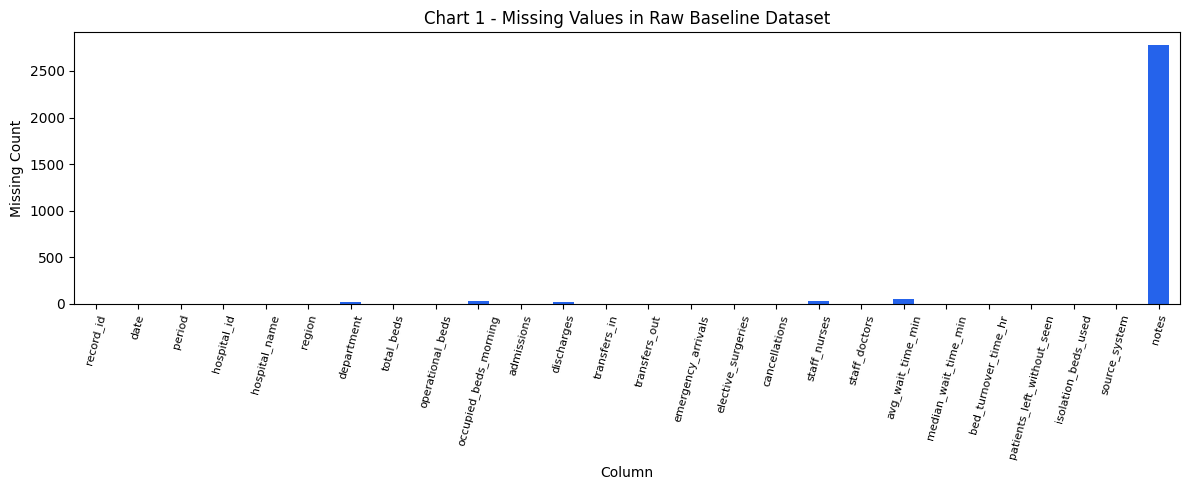

In [10]:
# Chart 1: Missing values in the raw data (missingness)
plt.figure(figsize=(12, 5))
baseline_raw.isnull().sum().plot(kind="bar", color="#2563EB")
plt.title("Chart 1 - Missing Values in Raw Baseline Dataset")
plt.xlabel("Column"); plt.ylabel("Missing Count")
plt.xticks(rotation=75, fontsize=8)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart1_missing_values.png", dpi=150)
plt.show()

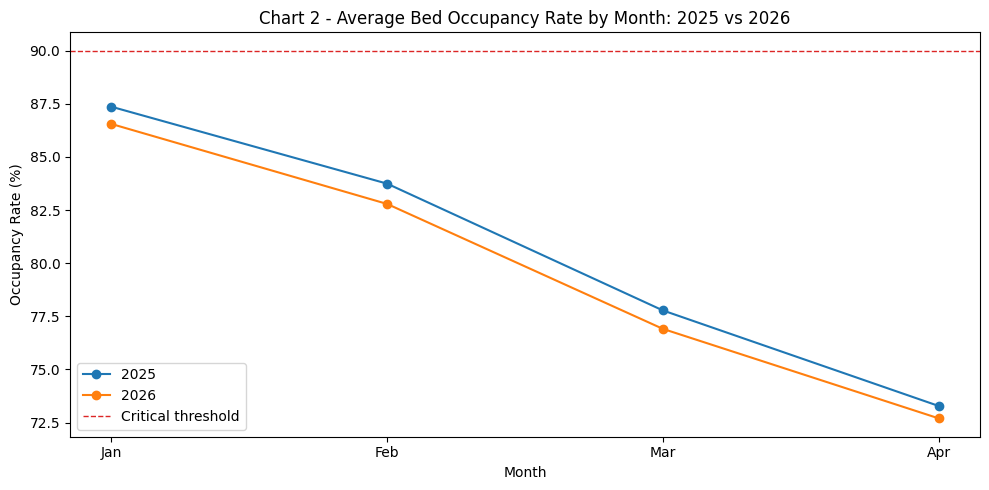

In [11]:
# Chart 2: Monthly occupancy-rate trend, 2025 vs 2026 (trends)
combined["month"] = combined["date"].dt.to_period("M").dt.to_timestamp()
monthly_occ = combined.groupby(["year", "month"])["occupancy_rate"].mean().reset_index()
plt.figure(figsize=(10, 5))
for yr, grp in monthly_occ.groupby("year"):
    plt.plot(grp["month"].dt.strftime("%b"), grp["occupancy_rate"] * 100, marker="o", label=str(yr))
plt.axhline(90, color="#DC2626", linestyle="--", linewidth=1, label="Critical threshold")
plt.title("Chart 2 - Average Bed Occupancy Rate by Month: 2025 vs 2026")
plt.xlabel("Month"); plt.ylabel("Occupancy Rate (%)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart2_occupancy_trend.png", dpi=150)
plt.show()

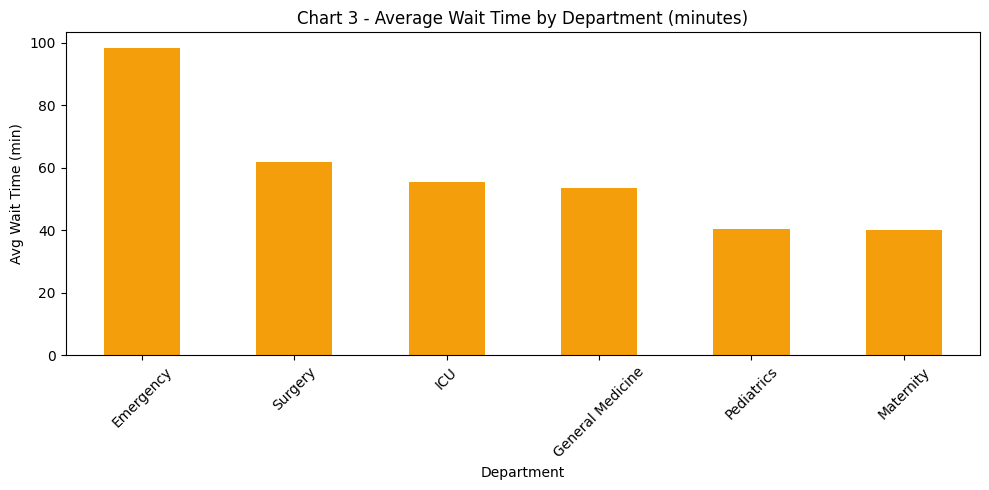

In [12]:
# Chart 3: Average wait time by department (segments)
dept_wait = segment_department["avg_wait_time_min"].sort_values(ascending=False)
plt.figure(figsize=(10, 5))
dept_wait.plot(kind="bar", color="#F59E0B")
plt.title("Chart 3 - Average Wait Time by Department (minutes)")
plt.xlabel("Department"); plt.ylabel("Avg Wait Time (min)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart3_wait_time_by_department.png", dpi=150)
plt.show()

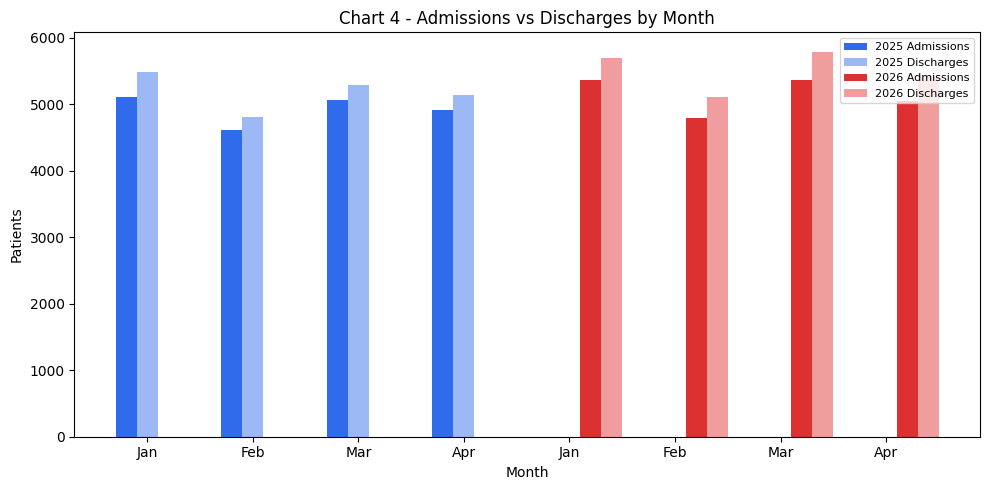

In [13]:
# Chart 4: Admissions vs discharges by month (flow balance)
monthly_flow = combined.groupby(["year", "month"])[["admissions", "discharges"]].sum().reset_index()
months = sorted(monthly_flow["month"].unique())
x = np.arange(len(months))
width = 0.2
fig, ax = plt.subplots(figsize=(10, 5))
colors = {2025: "#2563EB", 2026: "#DC2626"}
for i, yr in enumerate(sorted(monthly_flow["year"].unique())):
    grp = monthly_flow[monthly_flow["year"] == yr].set_index("month").reindex(months)
    offset = (i - 0.5) * (2 * width)
    ax.bar(x + offset, grp["admissions"], width=width, color=colors[yr], alpha=0.95, label=f"{yr} Admissions")
    ax.bar(x + offset + width, grp["discharges"], width=width, color=colors[yr], alpha=0.45, label=f"{yr} Discharges")
ax.set_xticks(x)
ax.set_xticklabels([pd.Timestamp(m).strftime("%b") for m in months])
plt.title("Chart 4 - Admissions vs Discharges by Month")
plt.xlabel("Month"); plt.ylabel("Patients")
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart4_admissions_vs_discharges.png", dpi=150)
plt.show()

<Figure size 1000x500 with 0 Axes>

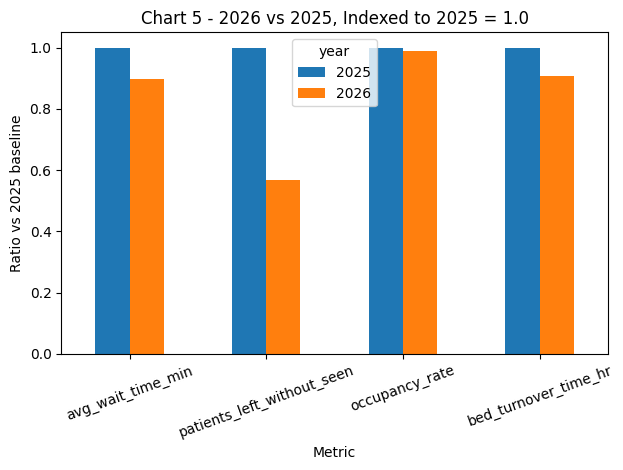

In [14]:
# Chart 5: Year-over-year comparison of key operational metrics (insight memo support)
key_metrics = ["avg_wait_time_min", "patients_left_without_seen", "occupancy_rate", "bed_turnover_time_hr"]
yearly_avg = combined.groupby("year")[key_metrics].mean()
yearly_avg_norm = yearly_avg / yearly_avg.loc[2025]  # indexed to 2025 = 1.0 so different units are comparable
plt.figure(figsize=(10, 5))
yearly_avg_norm.T.plot(kind="bar")
plt.title("Chart 5 - 2026 vs 2025, Indexed to 2025 = 1.0")
plt.xlabel("Metric"); plt.ylabel("Ratio vs 2025 baseline")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{CHART_DIR}/chart5_yoy_key_metrics.png", dpi=150)
plt.show()

## 12. Insight Memo (saved to file, not just printed)

In [15]:
avg_2025 = combined[combined["year"] == 2025]
avg_2026 = combined[combined["year"] == 2026]

memo_lines = []
memo_lines.append("# Hospital Capacity & Patient-Flow - Insight Memo\n")
memo_lines.append(f"Comparing Jan-Apr 2025 (baseline) vs Jan-Apr 2026 (comparison), "
                   f"{len(baseline_clean)} and {len(comparison_clean)} cleaned department-day records respectively.\n")

memo_lines.append("## Headline numbers\n")
for col, label, unit in [
    ("occupancy_rate", "Average bed occupancy rate", "ratio"),
    ("avg_wait_time_min", "Average wait time", "min"),
    ("patients_left_without_seen", "Patients who left without being seen (avg/record)", "patients"),
    ("bed_turnover_time_hr", "Average bed turnover time", "hr"),
]:
    a, b = avg_2025[col].mean(), avg_2026[col].mean()
    change = b - a
    pct = (change / a * 100) if a else float("nan")
    memo_lines.append(f"- **{label}**: {a:.2f} {unit} (2025) -> {b:.2f} {unit} (2026), "
                       f"change {change:+.2f} ({pct:+.1f}%)")

memo_lines.append("\n## Segment notes\n")
top_dept = segment_department["avg_occupancy_rate"].idxmax()
memo_lines.append(f"- **{top_dept}** runs the highest average occupancy rate of any department "
                   f"({segment_department.loc[top_dept, 'avg_occupancy_rate']*100:.1f}%) - "
                   f"a candidate for proactive bed-planning review.")
top_region = segment_region["avg_wait_time_min"].idxmax()
memo_lines.append(f"- **{top_region}** region has the longest average wait time "
                   f"({segment_region.loc[top_region, 'avg_wait_time_min']:.1f} min) of any region - "
                   f"worth a fairness/unequal-service follow-up (see Responsible Use notes).")

memo_lines.append("\n## Data-quality notes\n")
memo_lines.append(f"- {log_baseline['duplicates_removed']} duplicate rows removed from baseline, "
                   f"{log_comparison['duplicates_removed']} from comparison.")
memo_lines.append(f"- {log_baseline['capacity_violations_capped']} (baseline) and "
                   f"{log_comparison['capacity_violations_capped']} (comparison) records had occupied beds "
                   f"recorded above operational capacity; these were capped and flagged in `capacity_flag` "
                   f"rather than silently changed.")
memo_lines.append("- All dates were re-parsed against each record's stated reporting period to resolve "
                   "ambiguous day/month ordering coming from multiple source systems.")
memo_lines.append("\n## Caveat\n")
memo_lines.append("This is a descriptive comparison only. No predictive model was trained and no causal claims "
                   "are made; differences may reflect seasonality, source-system changes, or genuine operational "
                   "shifts and should be reviewed by hospital operations staff before acting on them.\n")

with open("insight_memo.md", "w") as f:
    f.write("\n".join(memo_lines))

from IPython.display import Markdown, display as ipy_display
ipy_display(Markdown("\n".join(memo_lines)))

# Hospital Capacity & Patient-Flow - Insight Memo

Comparing Jan-Apr 2025 (baseline) vs Jan-Apr 2026 (comparison), 2880 and 2880 cleaned department-day records respectively.

## Headline numbers

- **Average bed occupancy rate**: 0.81 ratio (2025) -> 0.80 ratio (2026), change -0.01 (-1.0%)
- **Average wait time**: 61.36 min (2025) -> 55.09 min (2026), change -6.26 (-10.2%)
- **Patients who left without being seen (avg/record)**: 0.46 patients (2025) -> 0.26 patients (2026), change -0.20 (-43.3%)
- **Average bed turnover time**: 4.67 hr (2025) -> 4.23 hr (2026), change -0.44 (-9.3%)

## Segment notes

- **ICU** runs the highest average occupancy rate of any department (90.9%) - a candidate for proactive bed-planning review.
- **West** region has the longest average wait time (61.6 min) of any region - worth a fairness/unequal-service follow-up (see Responsible Use notes).

## Data-quality notes

- 28 duplicate rows removed from baseline, 28 from comparison.
- 115 (baseline) and 95 (comparison) records had occupied beds recorded above operational capacity; these were capped and flagged in `capacity_flag` rather than silently changed.
- All dates were re-parsed against each record's stated reporting period to resolve ambiguous day/month ordering coming from multiple source systems.

## Caveat

This is a descriptive comparison only. No predictive model was trained and no causal claims are made; differences may reflect seasonality, source-system changes, or genuine operational shifts and should be reviewed by hospital operations staff before acting on them.


## 13. Data Limitations

- **Synthetic / illustrative data.** These exports are structured for this exercise; they
  should not be treated as real patient or hospital records.
- **Daily, department-level granularity only.** There's no patient-level row, so
  within-day variation (e.g. a single bad shift) is invisible at this resolution.
- **`occupied_beds_morning` is a single daily snapshot.** It says nothing about
  occupancy at other times of day, which can differ materially in Emergency.
- **The `notes` column is sparse by construction** (~5% of rows). Its absence on a
  row means "no flag was raised," not "this row was verified clean" — silence isn't
  proof of correctness.
- **Date ambiguity isn't fully resolvable in every case.** A handful of slash-format
  dates (`DD/MM/YYYY` vs `MM/DD/YYYY`) are inherently ambiguous when both
  components are ≤ 12; this notebook resolves them using each record's known
  reporting window as a constraint, which works here but would not catch an
  ambiguous error that *also* happens to fall inside a valid range.
- **Outlier clipping is a methodological choice, not ground truth.** Per-department
  IQR clipping on wait/turnover-time columns will still clip a handful of genuine
  extreme events (e.g. a real mass-casualty surge) alongside data-entry errors —
  by design, since this notebook can't tell those two cases apart from the data
  alone. Any clipped value is a candidate for manual review, not a confirmed error.
- **Two years of Jan–Apr only.** Four months from two years is not enough to
  separate a real trend from one unusual quarter; "2026 vs 2025" comparisons in the
  insight memo describe what happened, not a statistically validated trend.

## 14. Responsible AI / Risk Check

- **Privacy & confidentiality.** No patient names or direct identifiers appear in
  this dataset — all records are aggregated to hospital/department/day. Any
  real-world version of this workflow should confirm that upstream aggregation
  step happened before export, and restrict access to the raw exports
  appropriately.
- **Consent & data lineage.** `source_system` is kept as a lineage marker showing
  which IT system each row came from. In a real deployment this notebook assumes
  — and would need to confirm — that hospital IT already secured the appropriate
  consent/governance approval for this data to be extracted and analysed.
- **Clinical safety boundaries.** This notebook is descriptive only: no diagnosis,
  triage, treatment, or staffing decision is automated or recommended directly.
  `capacity_status` is a labelled threshold for *visibility*, not an instruction.
- **Unequal service impact.** Section 10's region/department breakdown exists
  specifically to surface disparities (e.g. one region's wait times running
  consistently higher) before they're used for any staffing or funding decision —
  any such finding should be reviewed with the affected sites, not acted on from
  the dashboard alone.
- **Failure modes (concrete, not hypothetical).** Section 6 documents six failure
  modes found by profiling *this exact dataset* — mixed date formats, mode-filling
  a sparse flag column, global outlier clipping erasing a department's real
  signal, unchecked capacity violations, NaN groupby keys silently dropping rows,
  and unflagged negative values. Anyone adapting this notebook to a new export
  should re-run section 5/6's diagnostics rather than assume the same fixes apply
  unchanged.
- **Human oversight.** All outputs here (charts, the insight memo, segment tables)
  are inputs to a conversation with qualified hospital operations staff, not a
  final decision. No output from this notebook should be acted on without that
  review.

## 15. Reproducibility

Re-running this notebook top-to-bottom on the two raw CSVs in this folder
regenerates every output file deterministically (no random sampling is used
anywhere in the pipeline):

- `cleaned_baseline_2025.csv`, `cleaned_comparison_2026.csv`, `combined_cleaned_hospital_data.csv`
- `data_dictionary.csv`
- `insight_memo.md`
- `charts/chart1_missing_values.png` … `charts/chart5_yoy_key_metrics.png`

**Requirements:** `pandas`, `numpy`, `matplotlib`, `python-dateutil` (see
`requirements.txt`).